# Network ReAct Agent - Demo Notebook
"Reasoning Loop with External State"

## Setup

In [11]:
import sys
from pathlib import Path

# Add src to path so we can import the package
sys.path.insert(0, str(Path.cwd().parent / "src"))

import json

from langchain_core.messages import HumanMessage

from network_manager_agent import (
    LLMConfig,
    build_agent,
    create_llm,
)
from network_manager_agent.data import DataManager

## Load Data

In [12]:
county_specialty_thresholds = {
    "mi": {
        "wayne": {"general practice": 10.0, "cardiology": 15.0},
        "washtenaw": {"general practice": 10.0, "cardiology": 15.0},
    }
}

dm = DataManager(county_specialty_thresholds=county_specialty_thresholds)
candidates = dm.get_candidates_df()
members = dm.get_members_df()
entity_summaries = dm.get_entity_summaries()
schema_profile = json.dumps(dm.get_schema_profile(), indent=2)

print(f"Loaded {len(candidates)} candidates, {len(members)} members, {len(entity_summaries)} entities")

Loaded 85615 candidates, 12051 members, 8609 entities


## Pre-compute: Filter & Aggregate (done by DataManager)

In [13]:
# DataManager handles loading, filtering, aggregation, and schema profiling automatically.
# See the Setup cell above for the current configuration.
print(f"Candidates: {len(dm.get_candidates_df())}, Members: {len(dm.get_members_df())}, Entities: {len(dm.get_entity_summaries())}")

Candidates: 85615, Members: 12051, Entities: 8609


## Create LLM

In [20]:
llm_config = LLMConfig(base_url="http://localhost:8080/v1")
llm = create_llm(llm_config)

# Quick test
response = llm.invoke("Hey there! Just making sure you're up and running!")
response.pretty_print()

================================== Ai Message ==================================

Hey! Yep, I'm up and running and ready to help. What can I do for you today? 😊


## Build Agent

In [21]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver

db_path = str(Path.cwd().parent / "checkpoints.sqlite")
conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = build_agent(llm, checkpointer=checkpointer)
print("Agent built successfully!")


Agent built successfully!


## Visualize Graph

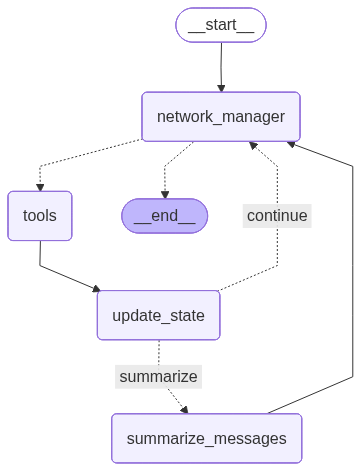

In [22]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Run the Agent

In [23]:
from network_manager_agent.ui import run_agent


def run_agent_demo(agent, inputs: dict, config: dict):
    """Wrapper for run_agent that matches the notebook's naming convention."""
    run_agent(agent, inputs, config)


In [24]:
# Create a thread
config = {"configurable": {"thread_id": "test_llama_cpp_mtp_2"}}


In [25]:
# Specify an input
messages = [HumanMessage(content='''
What is the entity with the most providers?
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
    "entity_summaries": entity_summaries,
    "schema_profile": schema_profile,
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "# Find the entity with the most providers using entity_summaries_df\nif 'provider_count' in entity_summaries_df.columns:\n    max_idx = entity_summaries_df['provider_count'].idxmax()\n    top_entity = entity_summaries_df.loc[max_idx]\n    result = {\"entity\": top_entity.name, \"provider_count\": top_entity[\"provider_count\"]}\nelse:\n    # Fallback: count from candidates_df\n    provider_counts = candidates_df.groupby(\"entity\").size().reset_index(name=\"provider_count\")\n    top_row = provider_counts.loc[provider_counts[\"provider_count\"].idxmax()]\n    result = {\"entity\": top_row[\"entity\"], \"provider_count\": top_row[\"provider_count\"]}"})

>>>> NODE: tools <<<<
   --- TOOL RESULT (run_code) ---
    result: {'entity': 5408, 'provider_count': np.int64(8684)}


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "# Get top 5 entities by provide

In [26]:
# Specify an input
messages = [HumanMessage(content='''
Now, add that entity to the network. Then report back with the network coverage.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> add_contract_entity({"entity_ids": ["mymichigan health"]})

>>>> NODE: tools <<<<
   --- TOOL RESULT (add_contract_entity) ---
    result: {"added_entities": ["mymichigan health"]}


>>>> NODE: update_state <<<<

>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "coverage, errors = compute_coverage(network_df, members_df, thresholds, candidates_df)\nresult = pd.DataFrame(coverage)"})

>>>> NODE: tools <<<<
   --- TOOL RESULT (run_code) ---
    result: [{"state": "mi", "county": "washtenaw", "specialty": "cardiology", "members_with_access": 1793, "total_members": 1794, "coverage_percentage": 99.94}, {"state": "mi", "county": "washtenaw", "specialty": "general practice", "members_with_access": 1520, "total_members": 1794, "coverage_percentage": 84.73}, {"state": "mi", "county": "wayne", "specialty": "cardiology", "members_with_access": 9339, "total_members": 10257, "coverag

In [27]:
# Specify an input
messages = [HumanMessage(content='''
Identify the members without access and provide a summary.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "import numpy as np\nfrom sklearn.neighbors import BallTree\n\ntarget_counties = ['wayne', 'washtenaw']\nspec_thresholds = {\n    'wayne': {'general practice': 10.0, 'cardiology': 15.0},\n    'washtenaw': {'general practice': 10.0, 'cardiology': 15.0}\n}\n\ntarget_members = members_df[(members_df['county'].str.lower().isin(target_counties)) & (members_df['state'].str.lower() == 'mi')].copy()\n\nuncovered_by_spec = {}\nall_uncovered_ids = set()\n\nfor county in target_counties:\n    county_mems = target_members[target_members['county'].str.lower() == county]\n    for spec, radius_miles in spec_thresholds[county].items():\n        spec_providers = network_df[network_df['specialty'].str.lower() == spec.lower()].dropna(subset=['lat', 'lon'])\n        \n        if spec_providers.empty:\n            uncovered_ids = county_mems['id'].tolist()\n        else:\n            radius_rad = radi

## Inspect Agent State

In [28]:
# Show the last human message from the conversation
state = agent.get_state(config)
messages = state.values.get("messages", [])
last_human = [m for m in reversed(messages) if m.type == 'human']
print("Last human message:")
print(last_human[0].content if last_human else "(none)")


Last human message:

Identify the members without access and provide a summary.



In [29]:
print("Summary:")
print(state.values.get("summary", "(empty)"))
print()

print("Entity summaries in state:")
print(f"  {len(state.values.get('entity_summaries', []))} entities loaded")
print()

print("Schema profile:")
schema = state.values.get("schema_profile", "")
print(f"  {len(schema)} chars" if schema else "  (empty)")


Summary:
Objective: What is the entity with the most providers? Now, add that entity to the network. Then report back with the network coverage.

Progress: Executed tool queries to retrieve entity IDs and provider counts from the candidate pool. Successfully queried the database and retrieved a ranked list of the top entities by provider volume. Awaiting network update and coverage calculation.

Key Findings: 
- Best entity found: MyMichigan Health: 8,684 providers
- Top 5 entities by provider count:
  1. MyMichigan Health: 8,684 providers
  2. Corewell Health: 8,506 providers
  3. Henry Ford Health: 5,135 providers
  4. Trinity Health: 3,890 providers
  5. VAMC (ALL): 1,751 providers

Remaining: Add MyMichigan Health to the network, compute the updated network coverage metrics, and report the final coverage results.

Entity summaries in state:
  8609 entities loaded

Schema profile:
  5185 chars


In [30]:
import pandas as pd
print("Current network (list of entity IDs):")
network = agent.get_state(config).values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty - no entities added yet)")


Current network (list of entity IDs):
  1. mymichigan health


## Try a More Complex Prompt

In [ ]:
# Reset with a new thread
# config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content='''
OK, now I'd like to add one more contract entity to the network. But I'd like to make sure this one has high effectiveness, but also one that best adds to the coverage. Find one, add it, and then report back on the status of the network.
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
    "entity_summaries": entity_summaries,
    "schema_profile": schema_profile,
}

run_agent_demo(agent, inputs, config)


In [ ]:
# Check final state
state = agent.get_state(config)
print("Summary:")
print(state.values.get("summary", "(empty)"))

print("\nNetwork (entity IDs):")
network = state.values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty)")
